# Jupyter Notebook  
Please note that this notebook is simply where the code was tested and developed.  
Most of the code has been updated and ajusted since the last execution to run as python files.  
This is essentially a draft notebook and is only included to show proof of developement as well as 
interesting outputs wihtin the developement such as mean and standard deviation calculations. 

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import time

In [1]:
from google.colab import drive
drive.mount('/content/drive')

train_path = './drive/MyDrive/Colab_Notebooks/AD_NC/train'
test_path = './drive/MyDrive/Colab_Notebooks/AD_NC/test'

import os
print(os.listdir(train_path))
print(os.listdir(test_path))

Mounted at /content/drive
['AD', 'NC', 'processed_AD', 'processed_NC']
['AD', 'NC', 'processed_NC', 'processed_AD']


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm # terminal progress bar this library lets us visualise the progress of an iterable
import cv2
import os
import numpy as np # Import numpy for image processing
import random
from collections import defaultdict # essentially a dict that does not raise a KeyError when accessing a nonexistent key

class ADNIDatasetTrain(Dataset):
    """
    ADNI Dataset for training data
    """
    def __init__(self, img_dir, transform=None, valid=False, seed=1, split_ratio=0.75, tqdm_disable=False): # change ratio if needed
        """
        Initialise dataset

        :Args:
                img_dir (str): Path to training directory containing images
                transform (callable, optional): Optional transform to be applied on a sample.
                valid (bool): True if validation set, False if training set
                seed (int): Seed for consistentency in random number generators
                split_ratio (float): how much of the training dataset we split to train on
                tqdm_disable (bool): Whether to disable the tqdm progress bar

        """
        self.img_dir = img_dir
        self.ad = img_dir + '/AD'
        self.nc = img_dir + '/NC'
        self.processed_ad = img_dir + '/processed_AD'
        self.processed_nc = img_dir + '/processed_NC'
        self.tqdm_disable = tqdm_disable

        # run preprocess on raw images
        self._preprocess_data()
        self.ad_images = [os.path.join(self.processed_ad, img) for img in os.listdir(self.processed_ad)]
        self.nc_images = [os.path.join(self.processed_nc, img) for img in os.listdir(self.processed_nc)]
        self.all_images = self.ad_images + self.nc_images
        self.all_labels = [1] * len(self.ad_images) + [0] * len(self.nc_images)

        self.transform = transform
        self.valid = valid
        self.seed = seed
        self.split_ratio = split_ratio

        self.mask = self._create_mask()

    def _create_mask(self):
        """
        Creates a mask for the dataset. Splits the training dataset into training and validation sets.

        :Args: None

        :Returns: List[bool]

        :Raises: None
        """
        random.seed(self.seed)
        if self.split_ratio == 1:
            return [True] * len(self.all_images)
        else:
            # split the data
            train_split = [random.random() < self.split_ratio for _ in range(len(self.all_images))]
            # validation data is images not used in training
            if self.valid:
                return [not x for x in train_split]
            return train_split

    def _preprocess_data(self):
        """
        Preprocess images in AD and NC directories
        These will be stored in processed_AD and processed_NC respectively

        :Args: None

        :Returns: None

        :Raises: None
        """
        # check processed AD directory exists
        if (not os.path.exists(self.processed_ad)):
            print("Preprocessing AD images")
            os.mkdir(self.processed_ad)
            for img in tqdm(os.listdir(self.ad), disable=self.tqdm_disable):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(self.ad, img)
                    new_path = os.path.join(self.processed_ad, img)
                    self._process_img(img_path, new_path)

        # check processed NC directory exists
        if (not os.path.exists(self.processed_nc)):
            print("Preprocessing NC images")
            os.mkdir(self.processed_nc)
            for img in tqdm(os.listdir(self.nc), disable=self.tqdm_disable):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(self.nc, img)
                    new_path = os.path.join(self.processed_nc, img)
                    self._process_img(img_path, new_path)

    def _process_img(self, raw_filepath, processed_filepath):
        """
        Process a single image. Image is cropped, resized, padded and saved.

        :Args:
                raw_filepath (str): Path to the raw image file
                processed_filepath (str): Path to save the processed image

        :Returns: None

        :Raises: None
        """
        # load in grayscale (since images are grayscale)
        image = cv2.imread(raw_filepath, cv2.IMREAD_GRAYSCALE)

        # Add the cropping logic here
        cropped_image = self._crop_brain_region(image)

        # we need to make sure all of the images are of the same pixel size.
        height, width = cropped_image.shape

        # resize the largest dimension 210 (since none of the images exceed this in terms of valid region)
        scaling = 210 / max(height, width)
        new_height = int(height * scaling)
        new_width = int(width * scaling)

        # resize image with lancoz interpolation
        cropped_image = cv2.resize(cropped_image, (new_width, new_height), interpolation=cv2.INTER_LANCZOS4)

        # Find padding values for 210x210 image
        pad_top = (210 - new_height) // 2
        pad_bottom = 210 - new_height - pad_top
        pad_left = (210 - new_width) // 2
        pad_right = 210 - new_width - pad_left

        # Add padding to the image
        pad_img = cv2.copyMakeBorder(cropped_image, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)

        # Save the processed image
        cv2.imwrite(processed_filepath, pad_img)

    def _crop_brain_region(self, image):
        """
        Seperate the brain region from the background and crop the image based
        on the bounding box of the brain region.

        :Args:
                image (np.array): image to be cropped

        :Returns:
                np.array: cropped image

        :Raises: None
        """

        # threshold the image using Otsu's threshold method
        _, binary_mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Find the coordinates of non-zero pixels
        coords = cv2.findNonZero(binary_mask)

        if coords is not None:
            # Get the bounding box of the non-zero pixels
            x, y, w, h = cv2.boundingRect(coords)

            # Crop the image using the bounding box
            cropped_image = image[y:y+h, x:x+w]
            return cropped_image
        else:
            # If no non-zero pixels are found, return the original image or handle as appropriate
            print("Error! Empty image - cropping has not been applied")
            return image

    def __len__(self):
        """
        Get length of dataset

        :Args: None

        :Returns:
                int: dataset length

        :Raises: None
        """
        return sum(self.mask)

    def __getitem__(self, idx):
        """
        Get image from dataset

        :Args:
                idx (int): index of image in dataset

        :Returns:
                tuple(np.array, int): image, label

        :Raises: IndexError
        """
        # Find the actual index in the full list based on the mask
        masked_idx = -1
        count = 0
        for i, include in enumerate(self.mask):
            if include:
                if count == idx:
                    masked_idx = i
                    break
                count += 1

        if masked_idx == -1:
            raise IndexError("Index out of bounds for masked dataset")

        img_path = self.all_images[masked_idx]
        label = self.all_labels[masked_idx]

        image = Image.open(img_path).convert('L') # Ensure image is in grayscale format

        if self.transform:
            image = self.transform(image)

        return image, label

class ADNIDatasetTest(Dataset):
    """
    ADNI Dataset for testing data
    """
    def __init__(self, img_dir, transform=None, tqdm_disable=False):
        """
        Initialise dataset

        :Args:
                img_dir (str): Path to training directory containing images
                transform (callable, optional): Optional transform to be applied on a sample.
                tqdm_disable (bool): Whether to disable the tqdm progress bar

        """
        self.img_dir = img_dir
        self.ad = img_dir + '/AD'
        self.nc = img_dir + '/NC'
        self.processed_ad = img_dir + '/processed_AD'
        self.processed_nc = img_dir + '/processed_NC'
        self.tqdm_disable = tqdm_disable
        self.transform = transform

        self._preprocess_data()

        self.img_groups = []
        self.img_groups.extend(self._group_images(self.processed_ad, 1))
        self.img_groups.extend(self._group_images(self.processed_nc, 0))

    def _preprocess_data(self):
        """
        Preprocess images in AD and NC directories
        These will be stored in processed_AD and processed_NC respectively

        :Args: None

        :Returns: None

        :Raises: None
        """
        # check processed AD directory exists
        if (not os.path.exists(self.processed_ad)):
            print("Preprocessing AD images")
            os.mkdir(self.processed_ad)
            for img in tqdm(os.listdir(self.ad), disable=self.tqdm_disable):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(self.ad, img)
                    new_path = os.path.join(self.processed_ad, img)
                    self._process_img(img_path, new_path)

        # check processed NC directory exists
        if (not os.path.exists(self.processed_nc)):
            print("Preprocessing NC images")
            os.mkdir(self.processed_nc)
            for img in tqdm(os.listdir(self.nc), disable=self.tqdm_disable):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(self.nc, img)
                    new_path = os.path.join(self.processed_nc, img)
                    self._process_img(img_path, new_path)

    def _process_img(self, raw_filepath, processed_filepath):
        """
        Process a single image. Image is cropped, resized, padded and saved.

        :Args:
                raw_filepath (str): Path to the raw image file
                processed_filepath (str): Path to save the processed image

        :Returns: None

        :Raises: None
        """
        # load in grayscale (since images are grayscale)
        image = cv2.imread(raw_filepath, cv2.IMREAD_GRAYSCALE)

        # Add the cropping logic here
        cropped_image = self._crop_brain_region(image)

        # we need to make sure all of the images are of the same pixel size.
        height, width = cropped_image.shape

        # resize the largest dimension 210 (since none of the images exceed this in terms of valid region)
        scaling = 210 / max(height, width)
        new_height = int(height * scaling)
        new_width = int(width * scaling)

        # resize image with lancoz interpolation
        cropped_image = cv2.resize(cropped_image, (new_width, new_height), interpolation=cv2.INTER_LANCZOS4)

        # Find padding values for 210x210 image
        pad_top = (210 - new_height) // 2
        pad_bottom = 210 - new_height - pad_top
        pad_left = (210 - new_width) // 2
        pad_right = 210 - new_width - pad_left

        # Add padding to the image
        pad_img = cv2.copyMakeBorder(cropped_image, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)

        # Save the processed image
        cv2.imwrite(processed_filepath, pad_img)

    def _crop_brain_region(self, image):
        """
        Seperate the brain region from the background and crop the image based
        on the bounding box of the brain region.

        :Args:
                image (np.array): image to be cropped

        :Returns:
                np.array: cropped image

        :Raises: None
        """
        # threshold the image using Otsu's threshold method
        _, binary_mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Find the coordinates of non-zero pixels
        coords = cv2.findNonZero(binary_mask)

        if coords is not None:
            # Get the bounding box of the non-zero pixels
            x, y, w, h = cv2.boundingRect(coords)

            # Crop the image using the bounding box
            cropped_image = image[y:y+h, x:x+w]
            return cropped_image
        else:
            # If no non-zero pixels are found, return the original image or handle as appropriate
            print("Error! Empty image - cropping has not been applied")
            return image

    def _group_images(self, dir, label):
        """
        Test images are given in groups, where the first number corresponds to
        a given brain. Group the images by their number, there should be 20 images per group

        :Args:
                dir (str): processed directory path
                label (int): 1 for AD, 0 for NC

        :Returns:
                List[dict]: a list of dictionaries containing the group number, filenames and label

        :Raises: None
        """
        img_groups = []
        unsorted_groups = defaultdict(list)

        for filename in os.listdir(dir):

            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Extract the group number from the filename
                group_number = filename.split('_')[0] # keep as str
                unsorted_groups[group_number].append(filename)

        # Sort the groups based on the group number
        for group_number, filenames in unsorted_groups.items():
            # sort filenames based on second number of filename
            sorted_group = sorted(filenames, key=lambda x: int(x.split('_')[1].split('.')[0]))

            # check group size is 20
            if len(sorted_group) != 20:
                # raise Exception(f"Group {group_number} does not contain excalty 20 images")
                print(f"Group {group_number} does not contain excalty 20 images")

            img_groups.append({
                "group_number" : group_number,
                "filenames" : sorted_group,
                "label" : label
            })

        return img_groups

    def __len__(self):
        """
        Get length of dataset

        :Args: None

        :Returns:
                int: dataset length

        :Raises: None
        """
        return len(self.img_groups)

    def __getitem__(self, idx):
        """
        Get image stack from dataset

        :Args:
                idx (int): index of image in dataset

        :Returns:
                tuple(torch.tensor, torch.tensor): image stack, label

        :Raises: IndexError
        """
        # grab image and labels
        group = self.img_groups[idx]
        group_num = group["group_number"]
        filenames = group["filenames"]
        label = group["label"]

        # initialise an empty image stack
        images_stacked = []

        # get target directory based on label
        image_dir = self.processed_ad if label == 1 else self.processed_nc

        for filename in filenames:
            img_path = os.path.join(image_dir, filename)

            # open image and convert to 8 bit grayscale
            image = Image.open(img_path).convert('L')

            # apply transform
            if self.transform:
                image = self.transform(image)

            # add image to image stack
            images_stacked.append(image)

        # use numpy to stack tensors since we have a list
        # images stacked to form (20, 1, 210, 210) shape
        images_stacked = np.stack(images_stacked, axis = 0)
        return torch.tensor(images_stacked, dtype=torch.float32), torch.tensor(label).float()


In [ ]:
"""
This code is adapted from the original implementation of GFNet
See:
    https://arxiv.org/abs/2107.00645
    https://github.com/raoyongming/GFNet
    https://github.com/raoyongming/GFNet/blob/master/gfnet.py#L266

The code has been adjusted for a binary classification problem
"""

import torch
import torch.nn as nn
import torch.fft
from timm.models.layers import DropPath, to_2tuple, trunc_normal_
import math
from functools import partial
from collections import OrderedDict

class PatchEmbedding(nn.Module):
    """
    Image to Patch embedding
    """
    def __init__(self, image_size=224, patch_size=14, in_chans=3, embed_dim=768):
        super().__init__()
        self.image_size = to_2tuple(image_size) # (image_size, image_size) tuple
        self.patch_size = to_2tuple(patch_size) # ensures that value is a tuple
        self.num_patches = (self.image_size[1] // self.patch_size[1]) * (self.image_size[0] // self.patch_size[0])

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=self.patch_size, stride=self.patch_size)

    def forward(self, x):
        # check size
        B, C, H, W = x.shape
        assert H == self.image_size[0] and W == self.image_size[1], \
            f"Input image size ({H}*{W}) does not match model ({self.image_size[0]} * {self.image_size[1]})"

        #
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class GlobalFilter(nn.Module):
    """
    global mixing in the spatial dimension
    """
    def __init__(self, dim, h=14, w=8):
        super().__init__()
        self.cmplx_weight = nn.Parameter(torch.randn(h, w, dim, 2, dtype=torch.float32)*0.02)
        self.w = w
        self.h = h

    def forward(self, x, spatial_size=None):
        B, N, C = x.shape
        if spatial_size is None:
            H = W = int(math.sqrt(N))
        else:
            H, W = spatial_size

        x = x.view(B, H, W, C)
        x = x.to(torch.float32)

        x = torch.fft.rfft2(x, dim=(1, 2), norm='ortho')
        weight = torch.view_as_complex(self.cmplx_weight)
        x = x * weight
        x = torch.fft.irfft2(x, s=(H, W), dim=(1, 2), norm='ortho')

        x = x.reshape(B, N, C)

        return x

class MultiLayerPerceptron(nn.Module):
    """
    Per-token depth-wise feature transformation

    MLP provides non-linearity to the global filter layer (with GELU) as well as
    channel interaction

    In the GFNet, the MLP consits of linear projection, activation function (GELU) and dropout layer
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.linear_layer_1 = nn.Linear(in_features, hidden_features)   # first linear projection
        self.activation_layer = act_layer()                             # activation layer
        self.linear_layer_2 = nn.Linear(hidden_features, out_features)  # second linear projection
        self.dropout_layer = nn.Dropout(drop)                           # dropout layer

    def forward(self, x):
        x = self.linear_layer_1(x)      # apply first linear projection
        x = self.activation_layer(x)    # apply activation layer
        x = self.dropout_layer(x)       # apply dropout layer
        x = self.linear_layer_2(x)      # apply second linear projection
        x = self.dropout_layer(x)       # apply dropout layer again
        return x

class Block(nn.Module):
    """
    GFNet Block, connects Global Filter layer and MLP layer
    """

    def __init__(self, dim, mlp_ratio=4., drop=0., drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm, h=14, w=8):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.filter = GlobalFilter(dim, h=h, w=w)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MultiLayerPerceptron(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.drop_path(self.mlp(self.norm2(self.filter(self.norm1(x)))))
        return x
class GFNet(nn.Module):

    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=1, embed_dim=768, depth=12,
                 mlp_ratio=4., representation_size=None, uniform_drop=False,
                 drop_rate=0., drop_path_rate=0., norm_layer=None,
                 dropcls=0):
        """
        num_classes = 1 for binary classification

        Args:
            img_size (int, tuple): input image size
            patch_size (int, tuple): patch size
            in_chans (int): number of input channels
            num_classes (int): number of classes for classification head
            embed_dim (int): embedding dimension
            depth (int): depth of transformer
            num_heads (int): number of attention heads
            mlp_ratio (int): ratio of mlp hidden dim to embedding dim
            qkv_bias (bool): enable bias for qkv if True
            qk_scale (float): override default qk scale of head_dim ** -0.5 if set
            representation_size (Optional[int]): enable and set representation layer (pre-logits) to this value if set
            drop_rate (float): dropout rate
            attn_drop_rate (float): attention dropout rate
            drop_path_rate (float): stochastic depth rate
            hybrid_backbone (nn.Module): CNN backbone to use in-place of PatchEmbed module
            norm_layer: (nn.Module): normalization layer
        """
        super().__init__()
        self.num_classes = num_classes
        self.num_features = self.embed_dim = embed_dim  # num_features for consistency with other models
        norm_layer = norm_layer or partial(nn.LayerNorm, eps=1e-6)

        self.patch_embed = PatchEmbedding(
                image_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        h = img_size // patch_size
        w = h // 2 + 1

        if uniform_drop:
            print('using uniform droppath with expect rate', drop_path_rate)
            dpr = [drop_path_rate for _ in range(depth)]  # stochastic depth decay rule
        else:
            # print('using linear droppath with expect rate', drop_path_rate * 0.5)
            dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]  # stochastic depth decay rule
        # dpr = [drop_path_rate for _ in range(depth)]  # stochastic depth decay rule

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, mlp_ratio=mlp_ratio,
                drop=drop_rate, drop_path=dpr[i], norm_layer=norm_layer, h=h, w=w)
            for i in range(depth)])

        self.norm = norm_layer(embed_dim)

        # Representation layer
        if representation_size:
            self.num_features = representation_size
            self.pre_logits = nn.Sequential(OrderedDict([
                ('fc', nn.Linear(embed_dim, representation_size)),
                ('act', nn.Tanh())
            ]))
        else:
            self.pre_logits = nn.Identity()

        # Classifier head
        self.head = nn.Linear(self.num_features, num_classes) if num_classes > 0 else nn.Identity()

        if dropcls > 0:
            print('dropout %.2f before classifier' % dropcls)
            self.final_dropout = nn.Dropout(p=dropcls)
        else:
            self.final_dropout = nn.Identity()

        trunc_normal_(self.pos_embed, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'pos_embed', 'cls_token'}

    def get_classifier(self):
        return self.head

    def reset_classifier(self, num_classes, global_pool=''):
        self.num_classes = num_classes
        self.head = nn.Linear(self.embed_dim, num_classes) if num_classes > 0 else nn.Identity()

    def forward_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x).mean(1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.final_dropout(x)
        x = self.head(x)
        return x

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
# run this on the CPU, it's much faster
from PIL import Image
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import os

# find avg mean and std in training dataset
ac_path = "./drive/MyDrive/Colab_Notebooks/AD_NC/train/AD"
nc_path = "./drive/MyDrive/Colab_Notebooks/AD_NC/train/NC"
paths=[ac_path, nc_path]

total_mean = 0
total_std = 0
total_images = 0

transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(210, 210), scale=(0.95, 1.02), ratio=(0.95, 1.05)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.98, 1.02)),
    transforms.RandomApply([transforms.ElasticTransform(alpha=10.0, sigma=3.0)], p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.4, scale=(0.01, 0.10), ratio=(0.5, 2.0))
])

for path in paths:
    for img_path in tqdm(os.listdir(path), disable=False):
        total_images += 1

        img = Image.open(os.path.join(path, img_path))

        img_tranform = transform(img)
        total_mean += img_tranform.mean().item()
        total_std += img_tranform.std().item()
    print(total_mean/total_images, total_std/total_images)

mean = total_mean / total_images
std = total_std / total_images
print("Mean: ", mean, "Std: ", std)

100%|██████████| 10401/10401 [05:42<00:00, 30.40it/s]


0.1106733745863897 0.2142825678654238


100%|██████████| 11124/11124 [06:16<00:00, 29.53it/s]

0.11486841564676334 0.21826585544938487
Mean:  0.11486841564676334 Std:  0.21826585544938487


In [ ]:
test_path = os.path.join(nc_path, "808819_91.jpeg")
test_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(210, 210), scale=(0.95, 1.02), ratio=(0.95, 1.05)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.98, 1.02)),
    transforms.RandomApply([transforms.ElasticTransform(alpha=10.0, sigma=3.0)], p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.4, scale=(0.01, 0.10), ratio=(0.5, 2.0)),
    transforms.Normalize(mean, std)
])

img = Image.open(test_path)
img_norm = test_transform(img)
mean_norm = img_norm.mean()
std_norm = img_norm.std()
print("Mean norm: ", mean_norm, "Std norm: ", std_norm)

Mean norm:  tensor(-0.0103) Std norm:  tensor(1.0697)


In [ ]:
import torch
import numpy as np
import random
from torchvision import transforms
from torch.utils.data import DataLoader

MEAN = 0.11486841564676334
STD = 0.21826585544938487

# Params ==========
disable_tqdm = False
test_seed = 10
train_path = './drive/MyDrive/Colab_Notebooks/AD_NC/train'
test_path = './drive/MyDrive/Colab_Notebooks/AD_NC/test'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def set_seed(seed: int):
    """
    Sets the seed of the random elements of the code in order to maintain consistency between trainings
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Use this for CUDA
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# https://apxml.com/courses/pytorch-for-tensorflow-developers/chapter-3-pytorch-data-loading-for-tf-users/data-augmentation-pytorch-torchvision
# apply geometric transforms before colour

# don't apply colour transformations since grayscale
def get_transforms(train):
    if train:
        data_transforms = transforms.Compose([
            transforms.RandomResizedCrop(size=(210, 210), scale=(0.95, 1.02), ratio=(0.95, 1.05)),
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.98, 1.02)),
            transforms.RandomApply([transforms.ElasticTransform(alpha=10.0, sigma=3.0)], p=0.3),
            transforms.ToTensor(),
            transforms.RandomErasing(p=0.4, scale=(0.01, 0.10), ratio=(0.5, 2.0)),
            transforms.Normalize(mean=[MEAN], std=[STD])
        ])
    else:
        data_transforms = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[MEAN], std=[STD])
        ])
    return data_transforms

set_seed(test_seed)

# the data preprocessing is actually faster on the CPU than the GPU, so we run on the CPU first
train_transforms = get_transforms(True)
test_transforms = get_transforms(False)

train_dataset = ADNIDatasetTrain(train_path, valid = False, transform=train_transforms, tqdm_disable=disable_tqdm)
valid_dataset = ADNIDatasetTrain(train_path, valid = True, transform=train_transforms, tqdm_disable=disable_tqdm)
test_dataset = ADNIDatasetTest(test_path, transform=test_transforms, tqdm_disable=disable_tqdm)


cuda


In [ ]:
import torch.optim as optim
import copy
import pickle
import os

MAX_EPOCHS = 75
# MAX_EPOCHS = 2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4

# https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html
# train 1 epoch function
def train_one_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device="cuda", visualise=False):
    """

    """
    model.train()
    total_train_loss = 0
    pred_correct = 0
    batch_total = 0

    # i -> batch number, images -> img list for batch, labels -> labels list for batch
    for images, labels in tqdm(train_loader, disable=not visualise, desc="Training... "): # for each batch of images
        # send the batch to the device
        images = images.to(device)
        labels = labels.float().to(device)

        # optimizer.zero_grad()

        outputs = model(images)             # 1. forward pass
        outputs = outputs.squeeze(1)
        loss = criterion(outputs, labels)   # 2. loss calculation
        optimizer.zero_grad()               # 3. zero the parameter gradients before backwards pass
        loss.backward()                     # 4. backwards pass
        optimizer.step()                    # 5. optimiser

        # update params
        total_train_loss += loss.item()     # add current loss to total loss
        predicted = (outputs >= 0).float()  # converting predictions to floats (1.0 or 0.0)
        batch_total += labels.size(0)       # add current batch size
        pred_correct += (predicted == labels).sum().item()
                                            # add the total correct predictions in current batch
    scheduler.step()                        # 6. scheduler

    avg_loss = total_train_loss / len(train_loader)     # average loss throughout epoch
    train_accuracy = pred_correct / batch_total               # model accuracy of epoch

    return avg_loss, train_accuracy

# evaluate model using validation set
def validate_model(model, valid_loader, criterion, device="cuda", visualise=False):
    model.eval()
    total_valid_loss = 0
    pred_correct = 0
    batch_total = 0
    with torch.no_grad():
        for images, labels in tqdm(valid_loader, disable=not visualise, desc="Validating... "):
            # send the batch to the device
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)             # 1. forward pass
            outputs = outputs.squeeze(1)        # squeeze outputs to match [64] shape of labels
            loss = criterion(outputs, labels)   # 2. loss calculation

            # update params
            total_valid_loss += loss.item()     # add current loss to total loss
            predicted = (outputs >= 0).float()  # converting predictions to floats (1.0 or 0.0)
            batch_total += labels.size(0)       # add current batch size
            pred_correct += (predicted == labels).sum().item()
                                            # add the total correct predictions in current batch

    avg_loss = total_valid_loss / len(valid_loader)     # average loss
    valid_accuracy = pred_correct / batch_total               # model accuracy

    return avg_loss, valid_accuracy

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=6)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False, num_workers=6)

model = GFNet(
    img_size=210,
    patch_size=14,
    in_chans=1,
    num_classes=1,
    embed_dim=384,
    depth=12,
    mlp_ratio=4.,
    norm_layer=partial(nn.LayerNorm, eps=1e-6)
).to(device)

# criterion = nn.CrossEntropyLoss()
criterion = nn.BCEWithLogitsLoss()
# scheduler
optimiser = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# optimiser = optim.SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=10, gamma=0.1) #added this
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=20, eta_min=1e-6)

# sched_lin_1 = torch.optim.lr_scheduler.CyclicLR(optimiser, base_lr=0.005, max_lr=LEARNING_RATE, step_size_up=15, step_size_down = 15, mode='triangular') #added this
# sched_lin_2 = torch.optim.lr_scheduler.LinearLR(optimiser, start_factor=0.005/LEARNING_RATE, end_factor=0.005/5) #added this
# scheduler = torch.optim.lr_scheduler.SequentialLR(optimiser, schedulers=[sched_lin_1, sched_lin_2], milestones=[30]) #added this

saving_filepath = './drive/MyDrive/Colab_Notebooks/Final_proj_stored'
train_loss_data = []
train_accuracy_data = []
valid_loss_data = []
valid_accuracy_data = []
top_valid_acc = 0
early_stop_count = 0
EARLY_STOP_VAL = 12

for epoch in range(MAX_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(epoch, model, train_loader, criterion, optimiser, scheduler, device=device, visualise=True)
    valid_loss, valid_accuracy = validate_model(model, valid_loader, criterion, device=device, visualise=True)

    train_loss_data.append(train_loss)
    train_accuracy_data.append(train_accuracy)
    valid_loss_data.append(valid_loss)
    valid_accuracy_data.append(valid_accuracy)

    print(f"Epoch: {epoch+1} Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Valid Loss: {valid_loss:.4f}, Valid Accuracy: {valid_accuracy:.4f}")

    # save the model if it is better than the current model
    if top_valid_acc < valid_accuracy:
        early_stop_count = 0
        top_valid_acc = valid_accuracy
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, os.path.join(saving_filepath, 'gfnet_model.pt'))
    else:
        early_stop_count += 1

    # stop the training early if there is no improvement in the last epochs
    if (early_stop_count > EARLY_STOP_VAL):
        print(f"No improvement in last {EARLY_STOP_VAL} epochs, stopping training")
        break

# save accuracy and loss data
with open(os.path.join(saving_filepath, 'train_loss_data.pkl'), 'wb') as f:
    pickle.dump(train_loss_data, f)

with open(os.path.join(saving_filepath, 'train_accuracy_data.pkl'), 'wb') as f:
    pickle.dump(train_accuracy_data, f)

with open(os.path.join(saving_filepath, 'valid_loss_data.pkl'), 'wb') as f:
    pickle.dump(valid_loss_data, f)

with open(os.path.join(saving_filepath, 'valid_accuracy_data.pkl'), 'wb') as f:
    pickle.dump(valid_accuracy_data, f)


Validating... : 100%|██████████| 84/84 [00:13<00:00,  6.03it/s]


Epoch: 1 Train Loss: 0.6777, Train Accuracy: 0.5761, Valid Loss: 0.6234, Valid Accuracy: 0.6575


Validating... : 100%|██████████| 84/84 [00:13<00:00,  6.14it/s]


Epoch: 2 Train Loss: 0.6177, Train Accuracy: 0.6553, Valid Loss: 0.6031, Valid Accuracy: 0.6603


Validating... : 100%|██████████| 84/84 [00:13<00:00,  6.07it/s]


...

Epoch: 68 Train Loss: 0.0649, Train Accuracy: 0.9752, Valid Loss: 0.1479, Valid Accuracy: 0.9457


Validating... : 100%|██████████| 84/84 [00:13<00:00,  6.14it/s]


Epoch: 69 Train Loss: 0.0719, Train Accuracy: 0.9730, Valid Loss: 0.1328, Valid Accuracy: 0.9500


Validating... : 100%|██████████| 84/84 [00:13<00:00,  6.24it/s]


Epoch: 70 Train Loss: 0.0755, Train Accuracy: 0.9704, Valid Loss: 0.1337, Valid Accuracy: 0.9491
No improvement in last 12 epochs, stopping training


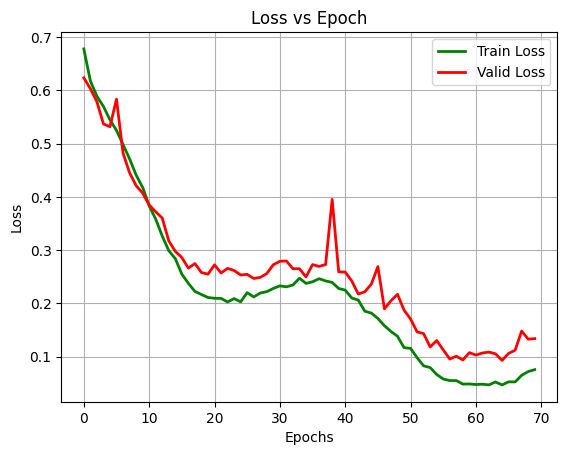

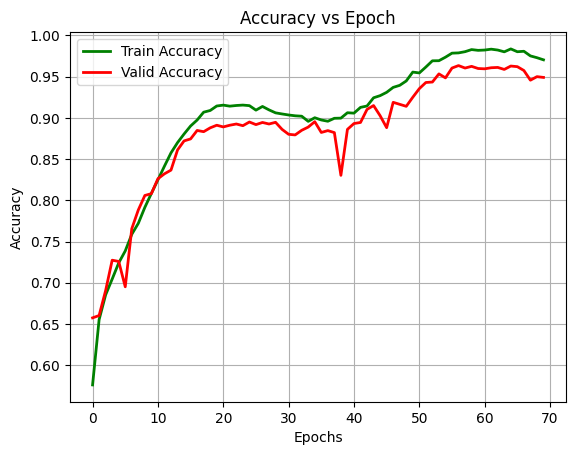

In [ ]:
import matplotlib.pyplot as plt
def plot_data():
    # load accuracy and loss data
    with open(os.path.join(saving_filepath, 'train_loss_data.pkl'), 'rb') as f:
        tld_load = pickle.load(f)

    with open(os.path.join(saving_filepath, 'train_accuracy_data.pkl'), 'rb') as f:
        tad_load = pickle.load(f)

    with open(os.path.join(saving_filepath, 'valid_loss_data.pkl'), 'rb') as f:
        vld_load = pickle.load(f)

    with open(os.path.join(saving_filepath, 'valid_accuracy_data.pkl'), 'rb') as f:
        vad_load = pickle.load(f)

    total_epochs = len(tld_load)
    ep = np.arange(0, total_epochs, 1)

    # plt.subplot(1, 2, 1)
    plt.plot(ep, tld_load, 'g', ep, vld_load, 'r', linewidth=2.0)
    plt.legend(['Train Loss', 'Valid Loss'])
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss vs Epoch')
    plt.grid()
    plt.savefig(os.path.join(saving_filepath, 'loss_vs_epoch.png'))
    plt.show()

    # plt.subplot(1, 2, 2)
    plt.plot(ep, tad_load, 'g', ep, vad_load, 'r', linewidth=2.0)
    plt.legend(['Train Accuracy', 'Valid Accuracy'])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epoch')
    plt.grid()
    plt.savefig(os.path.join(saving_filepath, 'acc_vs_epoch.png'))
    plt.show()

plot_data()


In [ ]:
# test model on test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

model.eval()

predictions_list = []
actual_values = []

for images, labels in tqdm(test_dataset, disable=False, desc="Testing... "):
    # send the batch to the device
    images = images.to(device)
    labels = labels.float().to(device)

    outputs = model(images)
    outputs = torch.sigmoid(outputs).mean().item()

    predictions = 1 if outputs >= 0.5 else 0
    predictions_list.append(predictions)
    actual_values.append(labels.item())


Testing... : 100%|██████████| 450/450 [00:29<00:00, 15.03it/s]


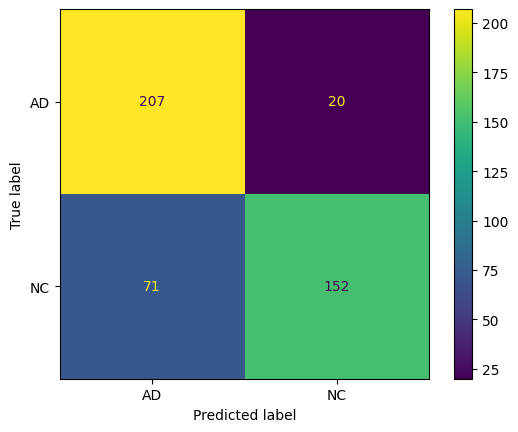

Testing accuracy:  0.7977777777777778


In [ ]:
cm = confusion_matrix(actual_values, predictions_list)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['AD', 'NC'])
disp.plot()
plt.show()

predictions_list = np.array(predictions_list)
actual_values = np.array(actual_values)

testing_accuracy = accuracy_score(actual_values, predictions_list)
print("Testing accuracy: ", testing_accuracy)

In [ ]:
report = classification_report(actual_values, predictions_list, target_names=['AD', 'NC'])
print(report)